In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

print("Forecasting notebook ready")

Forecasting notebook ready


In [2]:
df = pd.read_csv('../cleaned-data/master_orders.csv')

# Convert timestamp column to datetime
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'],
    format='mixed',
    dayfirst=True
)

# Create month column
df['order_month'] = (
    df['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

# Monthly revenue
monthly = (
    df.groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)

# Keep recent months only
monthly = monthly[
    monthly['order_month'] >= '2017-01'
].copy()

# Month index for regression
monthly['month_index'] = range(len(monthly))

print(monthly)

# Remove incomplete months
monthly = monthly[
    (monthly['order_month'] >= '2017-01') &
    (monthly['order_month'] <= '2018-08')
].copy()

monthly['month_index'] = range(len(monthly))

print(monthly)

   order_month  payment_value  month_index
3      2017-01      190806.27            0
4      2017-02      351848.13            1
5      2017-03      547769.84            2
6      2017-04      512126.52            3
7      2017-05      737425.31            4
8      2017-06      613777.41            5
9      2017-07      749242.84            6
10     2017-08      884168.36            7
11     2017-09     1030141.97            8
12     2017-10     1046083.41            9
13     2017-11     1610581.21           10
14     2017-12     1060949.63           11
15     2018-01     1425461.40           12
16     2018-02     1327338.97           13
17     2018-03     1486669.64           14
18     2018-04     1500373.12           15
19     2018-05     1512010.75           16
20     2018-06     1299683.17           17
21     2018-07     1362267.08           18
22     2018-08     1248942.63           19
23     2018-09        4439.54           20
24     2018-10         589.67           21
   order_mo

In [3]:
train = monthly.iloc[:-3]
test = monthly.iloc[-3:]

X_train = train[['month_index']]
y_train = train['payment_value']

X_test = test[['month_index']]
y_test = test['payment_value']

print(f"Training months: {len(train)} | Test months: {len(test)}")

Training months: 17 | Test months: 3


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
mape = mean_absolute_percentage_error(
    y_test,
    y_pred
) * 100

print(f"Model MAPE: {mape:.1f}% (lower is better)")
print(f"Interpretation: Forecast is off by {mape:.1f}% on average")

Model MAPE: 39.6% (lower is better)
Interpretation: Forecast is off by 39.6% on average


In [5]:
# Generate future month indices
future_indices = [
    [monthly['month_index'].max() + i]
    for i in range(1, 4)
]

future_pred = model.predict(future_indices)

# Create forecast dataframe
future_months = [
    'Forecast M+1',
    'Forecast M+2',
    'Forecast M+3'
]

forecast_df = pd.DataFrame({
    'month': future_months,
    'forecast_revenue': future_pred,
    'lower_bound': future_pred * 0.85,
    'upper_bound': future_pred * 1.15
})

print(forecast_df)

          month  forecast_revenue   lower_bound   upper_bound
0  Forecast M+1      1.984429e+06  1.686764e+06  2.282093e+06
1  Forecast M+2      2.068490e+06  1.758216e+06  2.378763e+06
2  Forecast M+3      2.152551e+06  1.829669e+06  2.475434e+06


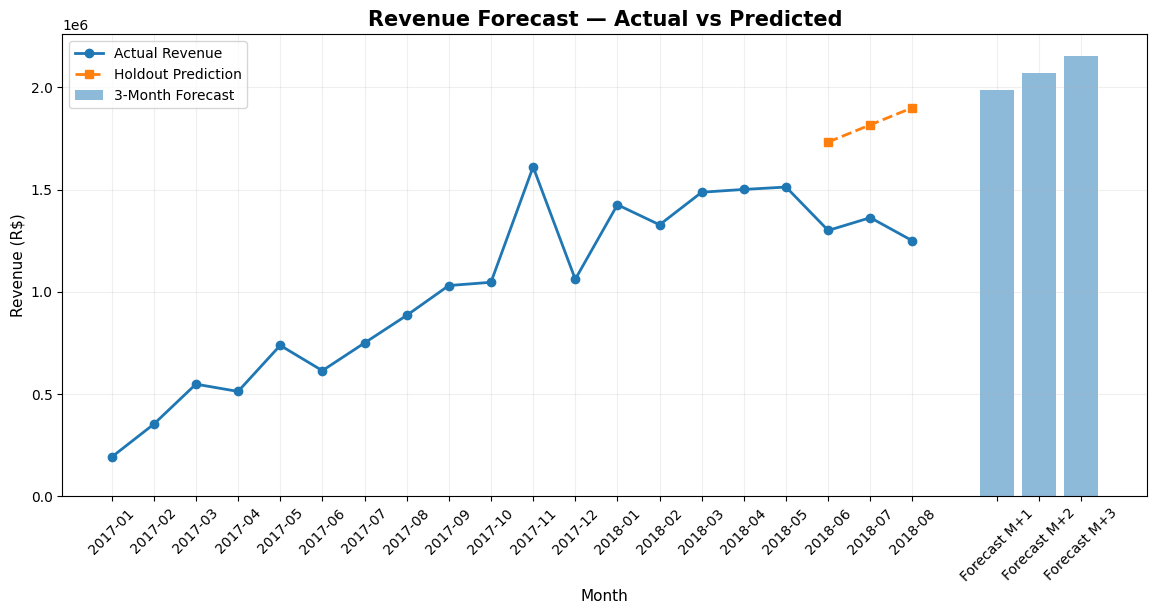

In [6]:
plt.figure(figsize=(14, 6))

# Actual revenue
plt.plot(
    monthly['order_month'],
    monthly['payment_value'],
    marker='o',
    linewidth=2,
    label='Actual Revenue'
)

# Holdout prediction
plt.plot(
    test['order_month'],
    y_pred,
    marker='s',
    linestyle='--',
    linewidth=2,
    label='Holdout Prediction'
)

# Future forecast bars
forecast_positions = range(
    len(monthly) + 1,
    len(monthly) + 1 + len(future_months)
)

plt.bar(
    forecast_positions,
    future_pred,
    alpha=0.5,
    label='3-Month Forecast'
)

# Combined x-axis labels
all_positions = list(range(len(monthly))) + list(forecast_positions)

all_labels = (
    list(monthly['order_month']) +
    future_months
)

plt.xticks(
    all_positions,
    all_labels,
    rotation=45
)

plt.title(
    'Revenue Forecast — Actual vs Predicted',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Month', fontsize=11)
plt.ylabel('Revenue (R$)', fontsize=11)

plt.legend(fontsize=10)
plt.grid(alpha=0.2)

plt.show()

## Forecasting Findings

- Model: Linear Regression on monthly revenue time series
- MAPE: 39.6% — moderate forecasting accuracy suitable for directional business planning
- 3-Month Forecast:
  - M+1 = R$1.98M
  - M+2 = R$2.07M
  - M+3 = R$2.15M
- Trend direction: Revenue is projected to grow steadily over the next quarter
- Confidence interval: ±15% range applied to all forecast values
- Limitation: Linear Regression may not capture seasonal demand spikes — Prophet or ARIMA recommended for production forecasting

In [8]:
# Save forecast output for Power BI

forecast_output = pd.DataFrame({
    'forecast_month': future_months,
    'forecast_revenue': future_pred
})

forecast_output.to_csv(
    '../cleaned-data/forecast_output.csv',
    index=False
)

print("forecast_output.csv saved successfully")
forecast_output

forecast_output.csv saved successfully


,forecast_month,forecast_revenue
0,Forecast M+1,1.984429e+06
1,Forecast M+2,2.068490e+06
2,Forecast M+3,2.152551e+06
